In [1]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn xgboost shap -q

In [2]:
import os
from google.colab import files

!mkdir -p project-ids/data/raw

uploaded = files.upload()  # Uploader archive.zip

!unzip -o archive.zip
!mv KDDTrain+.txt project-ids/data/raw/ 2>/dev/null || true
!mv KDDTest+.txt  project-ids/data/raw/ 2>/dev/null || true

print("✅ Fichiers disponibles :")
!ls project-ids/data/raw


Saving archive.zip to archive.zip
Archive:  archive.zip
  inflating: KDDTest+.arff           
  inflating: KDDTest+.txt            
  inflating: KDDTest-21.arff         
  inflating: KDDTest-21.txt          
  inflating: KDDTest1.jpg            
  inflating: KDDTrain+.arff          
  inflating: KDDTrain+.txt           
  inflating: KDDTrain+_20Percent.arff  
  inflating: KDDTrain+_20Percent.txt  
  inflating: KDDTrain1.jpg           
  inflating: index.html              
  inflating: nsl-kdd/KDDTest+.arff   
  inflating: nsl-kdd/KDDTest+.txt    
  inflating: nsl-kdd/KDDTest-21.arff  
  inflating: nsl-kdd/KDDTest-21.txt  
  inflating: nsl-kdd/KDDTest1.jpg    
  inflating: nsl-kdd/KDDTrain+.arff  
  inflating: nsl-kdd/KDDTrain+.txt   
  inflating: nsl-kdd/KDDTrain+_20Percent.arff  
  inflating: nsl-kdd/KDDTrain+_20Percent.txt  
  inflating: nsl-kdd/KDDTrain1.jpg   
  inflating: nsl-kdd/index.html      
✅ Fichiers disponibles :
KDDTest+.txt  KDDTrain+.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, time

print("✅ Bibliothèques importées.")

✅ Bibliothèques importées.


In [4]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_score"
]

train_df = pd.read_csv("project-ids/data/raw/KDDTrain+.txt", header=None, names=columns)
test_df  = pd.read_csv("project-ids/data/raw/KDDTest+.txt",  header=None, names=columns)

train_df = train_df.drop('difficulty_score', axis=1)
test_df  = test_df.drop('difficulty_score', axis=1)

print(f"✅ Train : {train_df.shape} | Test : {test_df.shape}")
print(f"   Valeurs manquantes : {train_df.isnull().sum().sum()}")
print(train_df.head(3))

✅ Train : (125973, 42) | Test : (22544, 42)
   Valeurs manquantes : 0
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10                    0.05   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.17                          0.0   
1                         0.88                          0.0   
2 

           duration     src_bytes     dst_bytes           land  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   
mean      287.14465  4.556674e+04  1.977911e+04       0.000198   
std      2604.51531  5.870331e+06  4.021269e+06       0.014086   
min         0.00000  0.000000e+00  0.000000e+00       0.000000   
25%         0.00000  0.000000e+00  0.000000e+00       0.000000   
50%         0.00000  4.400000e+01  0.000000e+00       0.000000   
75%         0.00000  2.760000e+02  5.160000e+02       0.000000   
max     42908.00000  1.379964e+09  1.309937e+09       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   125973.000000  125973.000000  125973.000000      125973.000000   
mean         0.022687       0.000111       0.204409           0.001222   
std          0.253530       0.014366       2.149968           0.045239   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000       0.00000

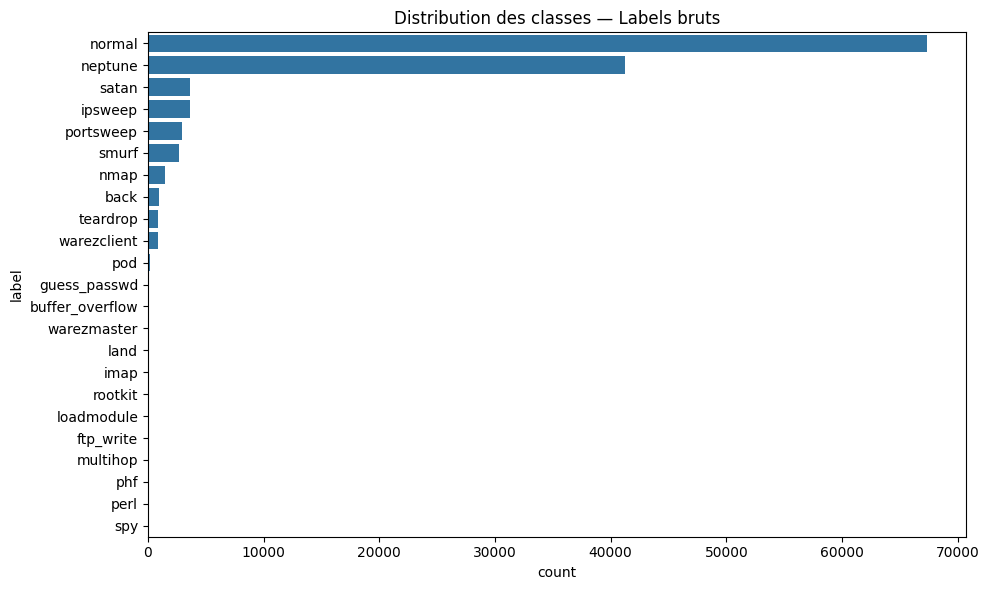

In [5]:
print(train_df.describe())
print(f"\nDistribution labels bruts :\n{train_df['label'].value_counts()}")

plt.figure(figsize=(10,6))
sns.countplot(y='label', data=train_df, order=train_df['label'].value_counts().index)
plt.title("Distribution des classes — Labels bruts")
plt.tight_layout()
plt.show()

✅ Distribution après regroupement (train) :
label
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Distribution (test) :
label
normal    9711
DoS       7460
Probe     2421
R2L       2421
U2R        531
Name: count, dtype: int64


/tmp/ipykernel_4751/2523277374.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=train_df,


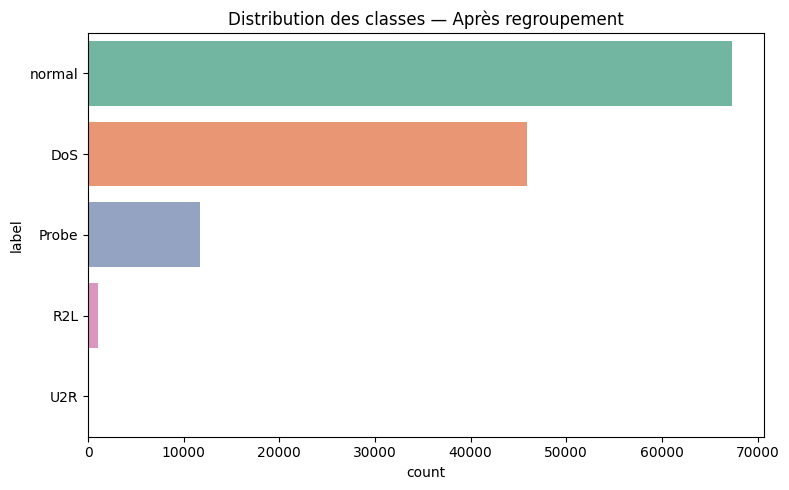

In [6]:
# Correction : httptunnel, sqlattack, xterm uniquement dans U2R
dos   = ['back','land','neptune','pod','smurf','teardrop',
         'apache2','udpstorm','processtable','worm','mailbomb']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy',
         'warezclient','warezmaster','snmpattack','named','xlock',
         'xsnoop','sendmail','snmpgetattack']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit',
         'httptunnel','ps','sqlattack','xterm']

def map_attack(label):
    label = label.split('.')[0].strip()
    if label == 'normal': return 'normal'
    elif label in dos:    return 'DoS'
    elif label in probe:  return 'Probe'
    elif label in r2l:    return 'R2L'
    elif label in u2r:    return 'U2R'
    else:                 return 'U2R'

train_df['label'] = train_df['label'].apply(map_attack)
test_df['label']  = test_df['label'].apply(map_attack)

print("✅ Distribution après regroupement (train) :")
print(train_df['label'].value_counts())
print("\nDistribution (test) :")
print(test_df['label'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(y='label', data=train_df,
              order=['normal','DoS','Probe','R2L','U2R'], palette='Set2')
plt.title("Distribution des classes — Après regroupement")
plt.tight_layout()
plt.show()

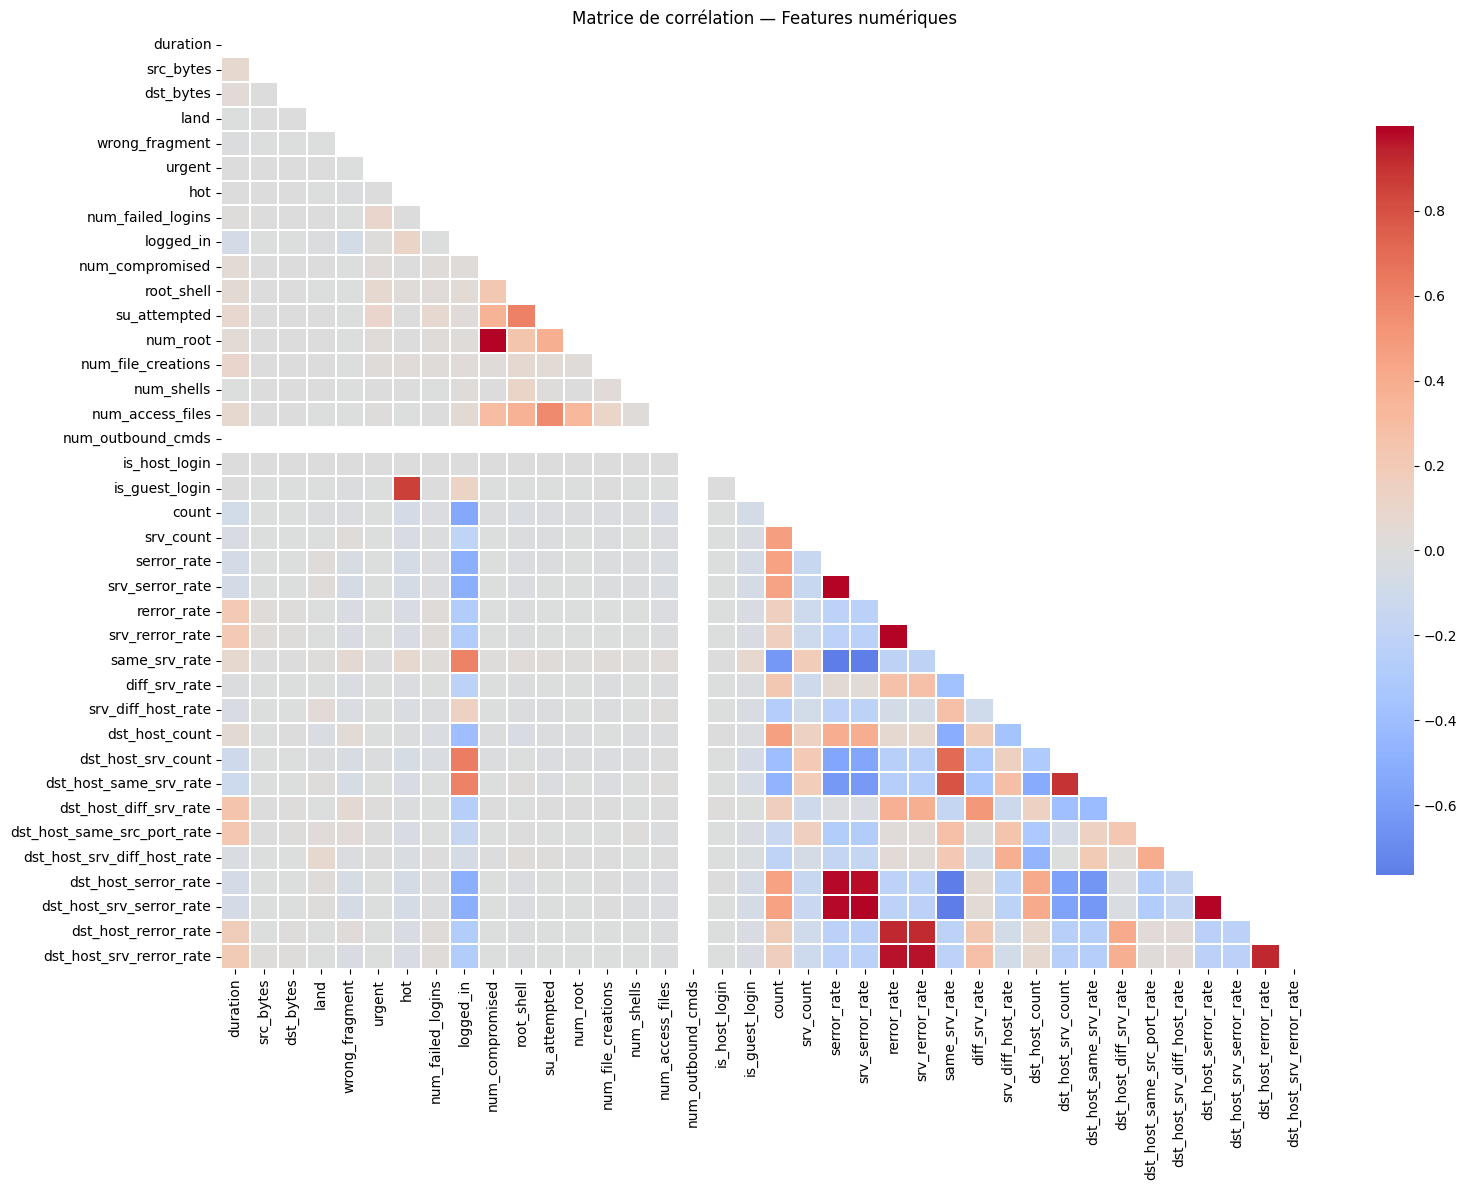

⚠️  Paires très corrélées (|r|>0.9) : 13
   num_root                                 ↔ num_compromised                           r=0.999
   srv_serror_rate                          ↔ serror_rate                               r=0.993
   srv_rerror_rate                          ↔ rerror_rate                               r=0.989
   dst_host_srv_serror_rate                 ↔ srv_serror_rate                           r=0.986
   dst_host_srv_serror_rate                 ↔ dst_host_serror_rate                      r=0.985
   dst_host_srv_serror_rate                 ↔ serror_rate                               r=0.981
   dst_host_serror_rate                     ↔ serror_rate                               r=0.979
   dst_host_serror_rate                     ↔ srv_serror_rate                           r=0.978
   dst_host_srv_rerror_rate                 ↔ srv_rerror_rate                           r=0.97
   dst_host_srv_rerror_rate                 ↔ rerror_rate                               r=0.964


/tmp/ipykernel_4751/1797106933.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=train_df,
/tmp/ipykernel_4751/1797106933.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=train_df,
/tmp/ipykernel_4751/1797106933.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=train_df,
/tmp/ipykernel_4751/1797106933.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=F

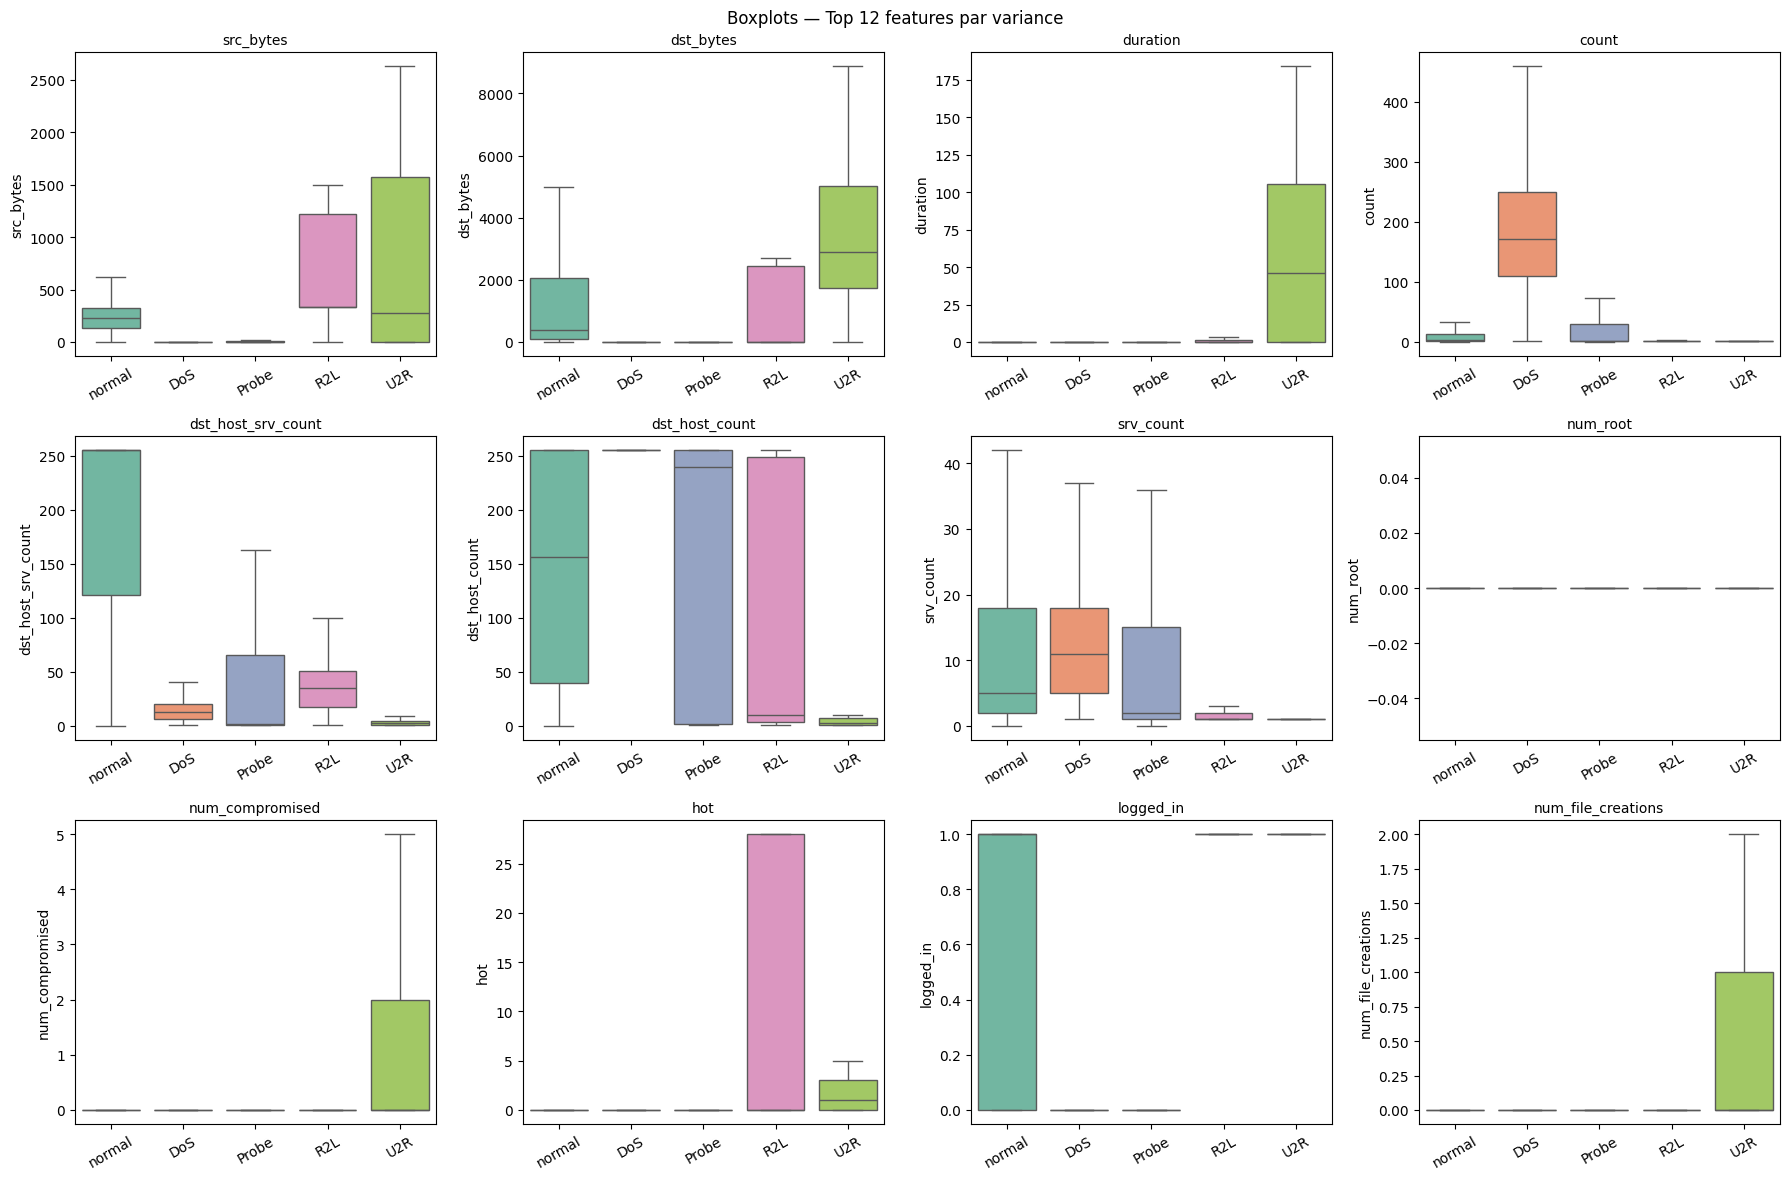

/tmp/ipykernel_4751/1797106933.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = train_df.groupby('label', group_keys=False).apply(



✅ Variance PCA — PC1:19.4%  PC2:15.4%  Total:34.8%


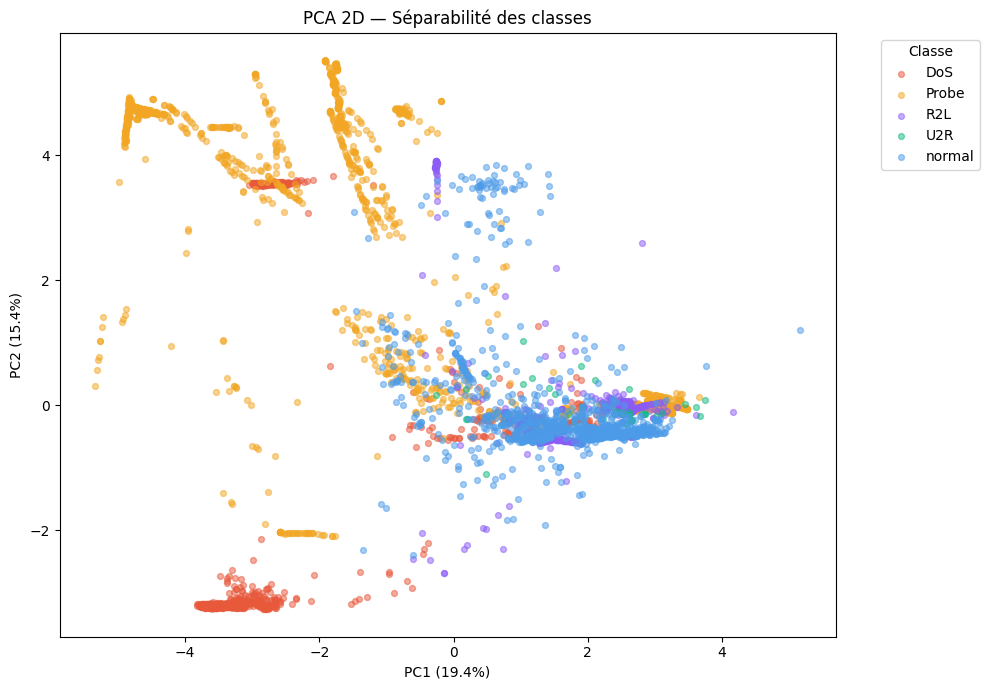

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SC_pca

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# --- Matrice de corrélation ---
plt.figure(figsize=(16,12))
corr = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, cbar_kws={"shrink":0.8})
plt.title("Matrice de corrélation — Features numériques")
plt.tight_layout()
plt.show()

high_corr = [
    (corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
    for i in range(len(corr.columns))
    for j in range(i)
    if abs(corr.iloc[i,j]) > 0.9
]
print(f"⚠️  Paires très corrélées (|r|>0.9) : {len(high_corr)}")
for a,b,r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"   {a:40s} ↔ {b:40s}  r={r}")

# --- Boxplots top 12 features ---
top_feats = train_df[numeric_cols].var().sort_values(ascending=False).head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(18,12))
for i, feat in enumerate(top_feats):
    sns.boxplot(x='label', y=feat, data=train_df,
                order=['normal','DoS','Probe','R2L','U2R'],
                palette='Set2', ax=axes.flatten()[i], showfliers=False)
    axes.flatten()[i].set_title(feat, fontsize=10)
    axes.flatten()[i].set_xlabel("")
    axes.flatten()[i].tick_params(axis='x', rotation=30)
plt.suptitle("Boxplots — Top 12 features par variance")
plt.tight_layout()
plt.show()

# --- PCA 2D ---
sample_df = train_df.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 1500), random_state=42))
X_pca_scaled = SC_pca().fit_transform(sample_df[numeric_cols])
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_pca_scaled)
explained = pca.explained_variance_ratio_ * 100
print(f"\n✅ Variance PCA — PC1:{explained[0]:.1f}%  PC2:{explained[1]:.1f}%  Total:{sum(explained):.1f}%")

pca_df  = pd.DataFrame({'PC1':X_2d[:,0],'PC2':X_2d[:,1],'label':sample_df['label'].values})
palette = {'normal':'#4C9BE8','DoS':'#E8593C','Probe':'#F2A623','R2L':'#8B5CF6','U2R':'#10B981'}
plt.figure(figsize=(10,7))
for lbl, grp in pca_df.groupby('label'):
    plt.scatter(grp['PC1'], grp['PC2'], label=lbl, alpha=0.5, s=18, color=palette[lbl])
plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
plt.title("PCA 2D — Séparabilité des classes")
plt.legend(title='Classe', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test  = test_df.drop('label', axis=1)
y_test  = test_df['label']

# One-hot encoding
X_train = pd.get_dummies(X_train, columns=['protocol_type','service','flag'])
X_test  = pd.get_dummies(X_test,  columns=['protocol_type','service','flag'])
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
feature_columns = X_train.columns.tolist()

print(f"✅ Shape après encodage — Train : {X_train.shape} | Test : {X_test.shape}")

# Normalisation (fitté uniquement sur train)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Normalisation terminée.")

✅ Shape après encodage — Train : (125973, 122) | Test : (22544, 122)
✅ Normalisation terminée.


In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

counts = pd.Series(y_train).value_counts()
print("Distribution avant SMOTE :\n", counts)

target_count      = int(counts['Probe'])
sampling_strategy = {'R2L': target_count, 'U2R': target_count}
print(f"\nObjectif : {sampling_strategy}")

smote = SMOTETomek(
    smote=SMOTE(sampling_strategy=sampling_strategy, k_neighbors=2, random_state=42),
    random_state=42
)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\n✅ Distribution après SMOTETomek :")
print(pd.Series(y_train_res).value_counts())

Distribution avant SMOTE :
 label
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Objectif : {'R2L': 11656, 'U2R': 11656}

✅ Distribution après SMOTETomek :
label
normal    67307
DoS       45915
U2R       11654
R2L       11649
Probe     11641
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train_res)
y_train_enc = le.transform(y_train_res)
y_test_enc  = le.transform(y_test)

print(f"✅ Classes : {le.classes_}")

✅ Classes : ['DoS' 'Probe' 'R2L' 'U2R' 'normal']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Logistic Regression — 681.4s ===
              precision    recall  f1-score   support

         DoS       0.96      0.82      0.88      7460
       Probe       0.72      0.79      0.76      2421
         R2L       0.90      0.30      0.45      2421
         U2R       0.08      0.07      0.08       531
      normal       0.72      0.91      0.81      9711

    accuracy                           0.78     22544
   macro avg       0.68      0.58      0.60     22544
weighted avg       0.81      0.78      0.77     22544



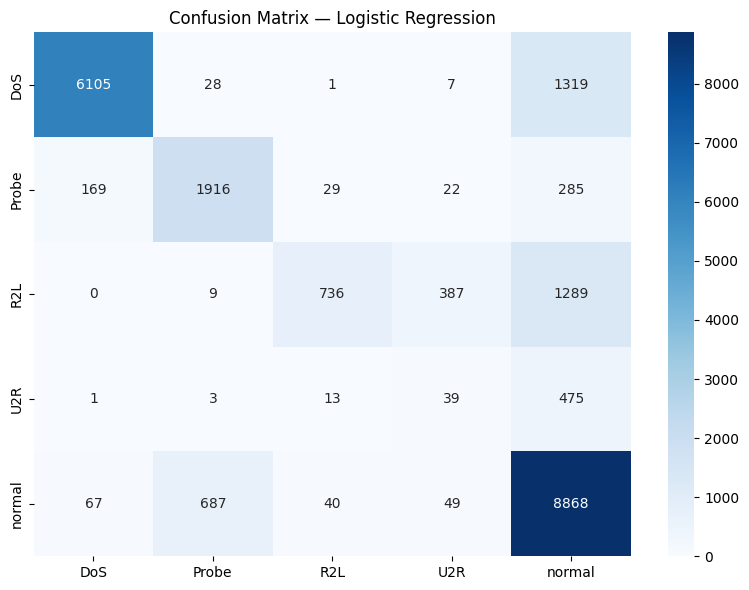


=== Decision Tree — 1.9s ===
              precision    recall  f1-score   support

         DoS       0.96      0.74      0.84      7460
       Probe       0.69      0.66      0.67      2421
         R2L       0.21      0.03      0.05      2421
         U2R       0.09      0.03      0.04       531
      normal       0.67      0.96      0.79      9711

    accuracy                           0.74     22544
   macro avg       0.52      0.48      0.48     22544
weighted avg       0.71      0.74      0.70     22544



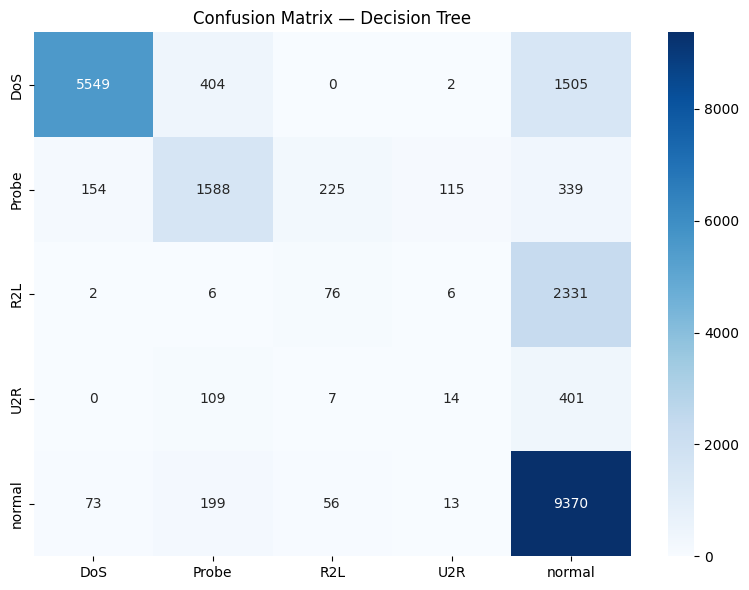

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced',
                                               solver='saga', random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=20, class_weight='balanced',
                                                  random_state=42)
}

baseline_results = {}
for name, model in baselines.items():
    t0    = time.time()
    model.fit(X_train_res, y_train_enc)
    y_pred  = le.inverse_transform(model.predict(X_test_scaled))
    elapsed = time.time() - t0
    f1      = f1_score(y_test, y_pred, average='weighted')
    baseline_results[name] = {'model': model, 'f1': f1}

    print(f"\n=== {name} — {elapsed:.1f}s ===")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(8,6))
    sns.heatmap(confusion_matrix(y_test, y_pred, labels=le.classes_),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

⏳ Entraînement Random Forest...
✅ Random Forest terminé.

              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7460
       Probe       0.86      0.59      0.70      2421
         R2L       0.94      0.03      0.05      2421
         U2R       0.67      0.02      0.03       531
      normal       0.64      0.97      0.77      9711

    accuracy                           0.74     22544
   macro avg       0.81      0.48      0.48     22544
weighted avg       0.80      0.74      0.70     22544



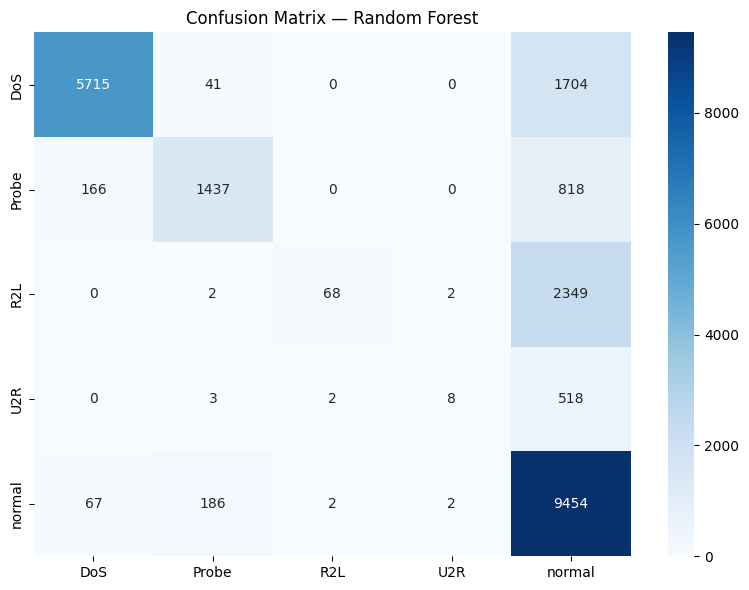

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=25, min_samples_leaf=1,
    class_weight={
        le.transform(['DoS'])[0]:     1,
        le.transform(['Probe'])[0]:   1,
        le.transform(['R2L'])[0]:    10,
        le.transform(['U2R'])[0]:    25,
        le.transform(['normal'])[0]:  1,
    },
    random_state=42, n_jobs=-1
)

print("⏳ Entraînement Random Forest...")
rf_model.fit(X_train_res, y_train_enc)
y_pred_rf = le.inverse_transform(rf_model.predict(X_test_scaled))
print("✅ Random Forest terminé.\n")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf, labels=le.classes_),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4751/3546986705.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_df.head(20), palette='viridis')


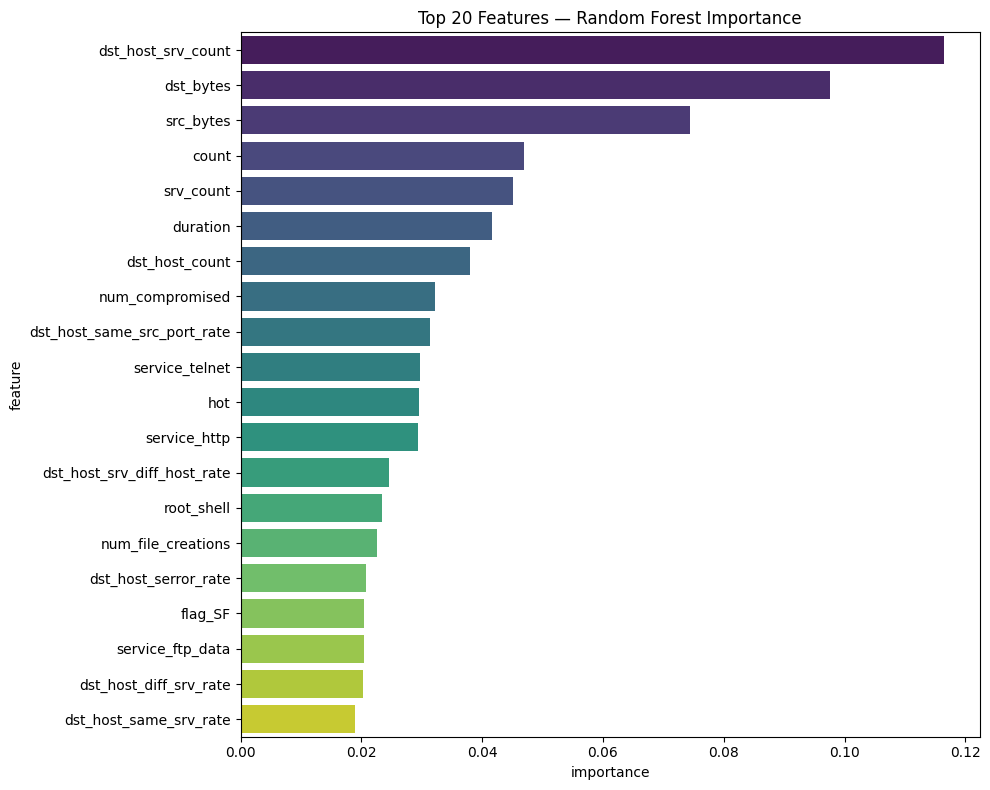

✅ Top 20 : ['dst_host_srv_count', 'dst_bytes', 'src_bytes', 'count', 'srv_count', 'duration', 'dst_host_count', 'num_compromised', 'dst_host_same_src_port_rate', 'service_telnet', 'hot', 'service_http', 'dst_host_srv_diff_host_rate', 'root_shell', 'num_file_creations', 'dst_host_serror_rate', 'flag_SF', 'service_ftp_data', 'dst_host_diff_srv_rate', 'dst_host_same_srv_rate']


In [13]:
feat_df = pd.DataFrame({
    'feature':    feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=feat_df.head(20), palette='viridis')
plt.title("Top 20 Features — Random Forest Importance")
plt.tight_layout()
plt.show()

print("✅ Top 20 :", feat_df.head(20)['feature'].tolist())

⏳ Entraînement XGBoost...
✅ XGBoost terminé.

              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7460
       Probe       0.83      0.65      0.73      2421
         R2L       0.98      0.14      0.25      2421
         U2R       0.62      0.04      0.07       531
      normal       0.67      0.97      0.80      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.52      0.54     22544
weighted avg       0.82      0.77      0.74     22544



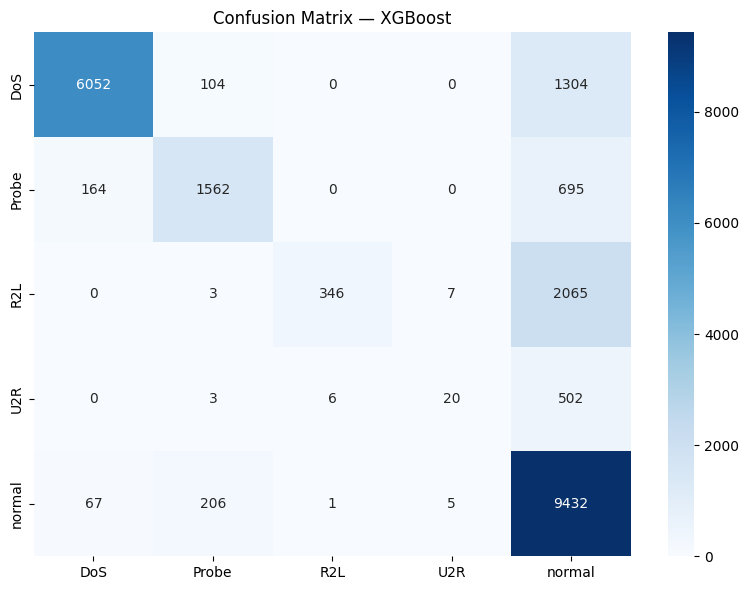

In [14]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

sample_weights = compute_sample_weight(
    class_weight={
        le.transform(['DoS'])[0]:     1,
        le.transform(['Probe'])[0]:   1,
        le.transform(['R2L'])[0]:    20,
        le.transform(['U2R'])[0]:    50,
        le.transform(['normal'])[0]:  1,
    },
    y=y_train_enc
)

xgb_model = XGBClassifier(
    n_estimators=500, max_depth=10, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9, min_child_weight=1,
    reg_alpha=0.1, reg_lambda=1, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)

print("⏳ Entraînement XGBoost...")
xgb_model.fit(X_train_res, y_train_enc, sample_weight=sample_weights)
y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test_scaled))
print("✅ XGBoost terminé.\n")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb, labels=le.classes_),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators':     [200, 300, 500],
        'max_depth':        [6, 8, 10],
        'learning_rate':    [0.01, 0.03, 0.05, 0.1],
        'subsample':        [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'min_child_weight': [1, 3],
    },
    n_iter=15, cv=skf, scoring='f1_weighted',
    n_jobs=-1, random_state=42, verbose=1
)

idx = np.random.RandomState(42).choice(len(X_train_res), 15000, replace=False)
print("⏳ RandomizedSearch XGBoost...")
xgb_search.fit(X_train_res[idx], y_train_enc[idx])
print(f"🏆 Meilleurs params : {xgb_search.best_params_}")
print(f"🏆 F1 validation    : {xgb_search.best_score_:.4f}")

# On remplace xgb_model par le meilleur modèle trouvé
best_xgb   = xgb_search.best_estimator_
y_pred_xgb = le.inverse_transform(best_xgb.predict(X_test_scaled))
print("\n=== RAPPORT BEST XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

⏳ RandomizedSearch XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
🏆 Meilleurs params : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
🏆 F1 validation    : 0.9969

=== RAPPORT BEST XGBoost ===
              precision    recall  f1-score   support

         DoS       0.95      0.84      0.89      7460
       Probe       0.79      0.61      0.69      2421
         R2L       0.99      0.20      0.34      2421
         U2R       0.61      0.04      0.08       531
      normal       0.70      0.97      0.81      9711

    accuracy                           0.78     22544
   macro avg       0.81      0.53      0.56     22544
weighted avg       0.82      0.78      0.76     22544



In [16]:
from sklearn.model_selection import cross_val_score

idx  = np.random.RandomState(42).choice(len(X_train_res), 10000, replace=False)
X_cv, y_cv = X_train_res[idx], y_train_enc[idx]
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Cross-validation Random Forest...")
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    X_cv, y_cv, cv=skf5, scoring='f1_weighted', n_jobs=-1
)
print(f"✅ RF  — F1 weighted : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

print("⏳ Cross-validation XGBoost...")
cv_xgb = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                  eval_metric='mlogloss', random_state=42, n_jobs=-1),
    X_cv, y_cv, cv=skf5, scoring='f1_weighted', n_jobs=-1
)
print(f"✅ XGB — F1 weighted : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

⏳ Cross-validation Random Forest...
✅ RF  — F1 weighted : 0.9952 ± 0.0013
⏳ Cross-validation XGBoost...
✅ XGB — F1 weighted : 0.9951 ± 0.0023


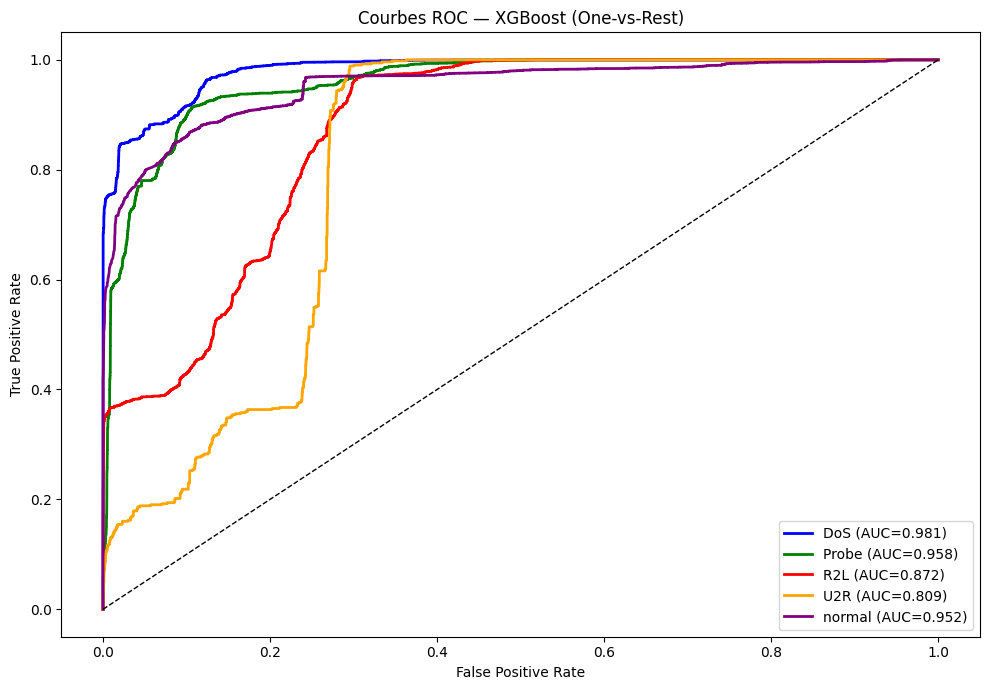

=== COMPARAISON F1 PAR CLASSE ===
Classe  F1 - Random Forest  F1 - XGBoost
   DoS               0.852         0.894
 Probe               0.703         0.685
   R2L               0.055         0.335
   U2R               0.029         0.081
normal               0.770         0.811


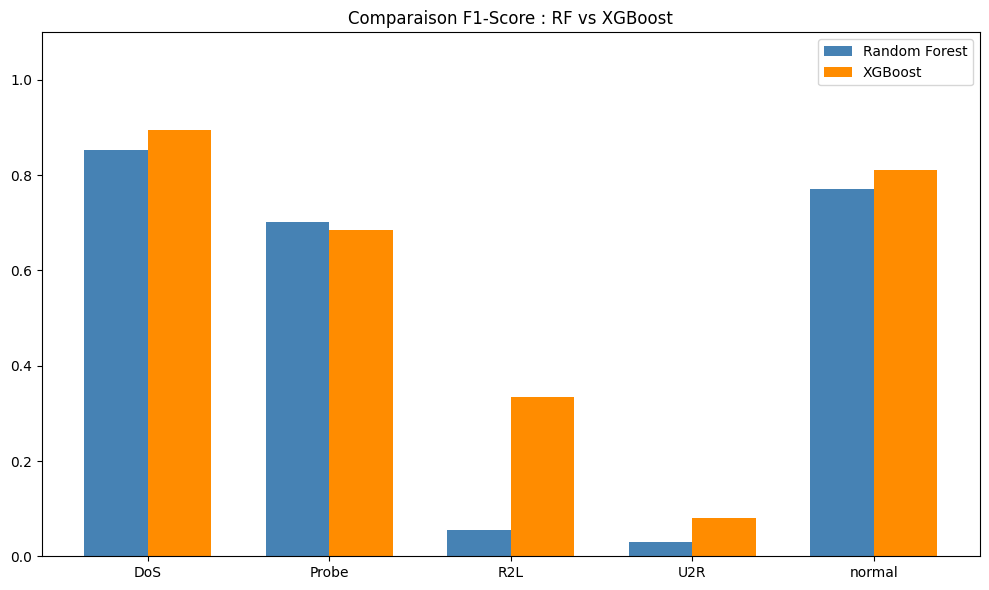

In [17]:
from sklearn.metrics import roc_curve, auc

y_test_bin = np.eye(len(le.classes_))[y_test_enc]
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)

plt.figure(figsize=(10,7))
colors = ['blue','green','red','orange','purple']
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_xgb[:,i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC — XGBoost (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Comparaison F1 par classe RF vs XGBoost
classes_all   = le.classes_
f1_rf_scores  = f1_score(y_test, y_pred_rf,  average=None, labels=classes_all)
f1_xgb_scores = f1_score(y_test, y_pred_xgb, average=None, labels=classes_all)

comp = pd.DataFrame({
    'Classe':             classes_all,
    'F1 - Random Forest': f1_rf_scores.round(3),
    'F1 - XGBoost':       f1_xgb_scores.round(3)
})
print("=== COMPARAISON F1 PAR CLASSE ===")
print(comp.to_string(index=False))

x = np.arange(len(classes_all)); w = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x-w/2, f1_rf_scores,  w, label='Random Forest', color='steelblue')
ax.bar(x+w/2, f1_xgb_scores, w, label='XGBoost',       color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(classes_all)
ax.set_ylim(0,1.1); ax.legend()
ax.set_title('Comparaison F1-Score : RF vs XGBoost')
plt.tight_layout()
plt.show()

=== TABLEAU COMPARATIF TOUS MODÈLES ===
             Modèle  Accuracy   F1-W  Precision  Recall
Logistic Regression    0.7835 0.7727     0.8069  0.7835
            XGBoost    0.7847 0.7564     0.8202  0.7847
      Decision Tree    0.7362 0.6976     0.7058  0.7362
      Random Forest    0.7400 0.6958     0.8019  0.7400


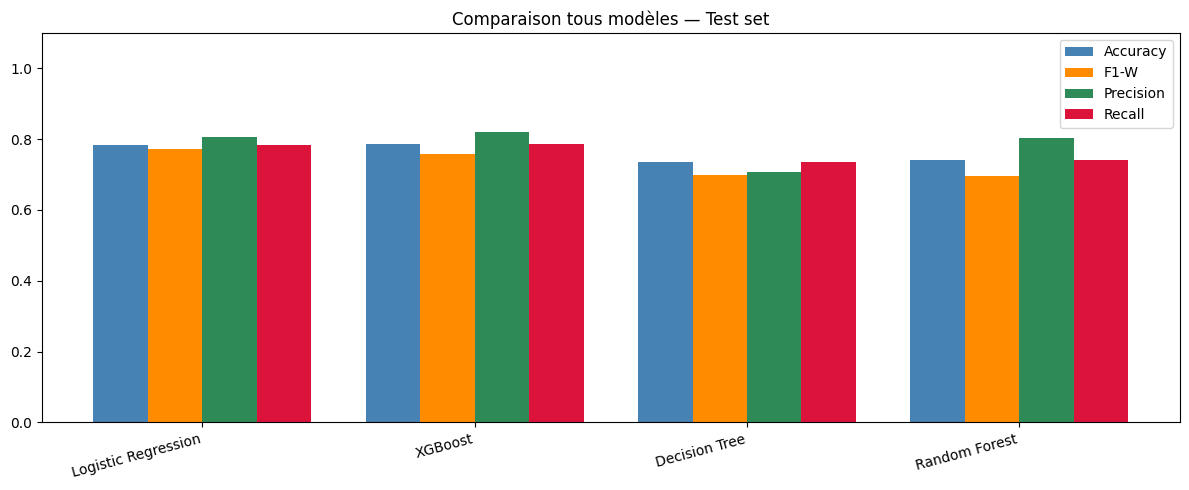

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

all_models = {
    **{k: v['model'] for k, v in baseline_results.items()},
    "Random Forest": rf_model,
    "XGBoost":       best_xgb,
}

rows = []
for name, model in all_models.items():
    y_pred = le.inverse_transform(model.predict(X_test_scaled))
    rows.append({
        'Modèle':    name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'F1-W':      round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
    })

comp_df = pd.DataFrame(rows).sort_values('F1-W', ascending=False)
print("=== TABLEAU COMPARATIF TOUS MODÈLES ===")
print(comp_df.to_string(index=False))

x = np.arange(len(comp_df)); w = 0.2
fig, ax = plt.subplots(figsize=(12,5))
for i, (m, c) in enumerate(zip(['Accuracy','F1-W','Precision','Recall'],
                                ['steelblue','darkorange','seagreen','crimson'])):
    ax.bar(x + i*w, comp_df[m], w, label=m, color=c)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(comp_df['Modèle'], rotation=15, ha='right')
ax.set_ylim(0,1.1); ax.legend()
ax.set_title("Comparaison tous modèles — Test set")
plt.tight_layout()
plt.show()

⏳ Calcul SHAP...


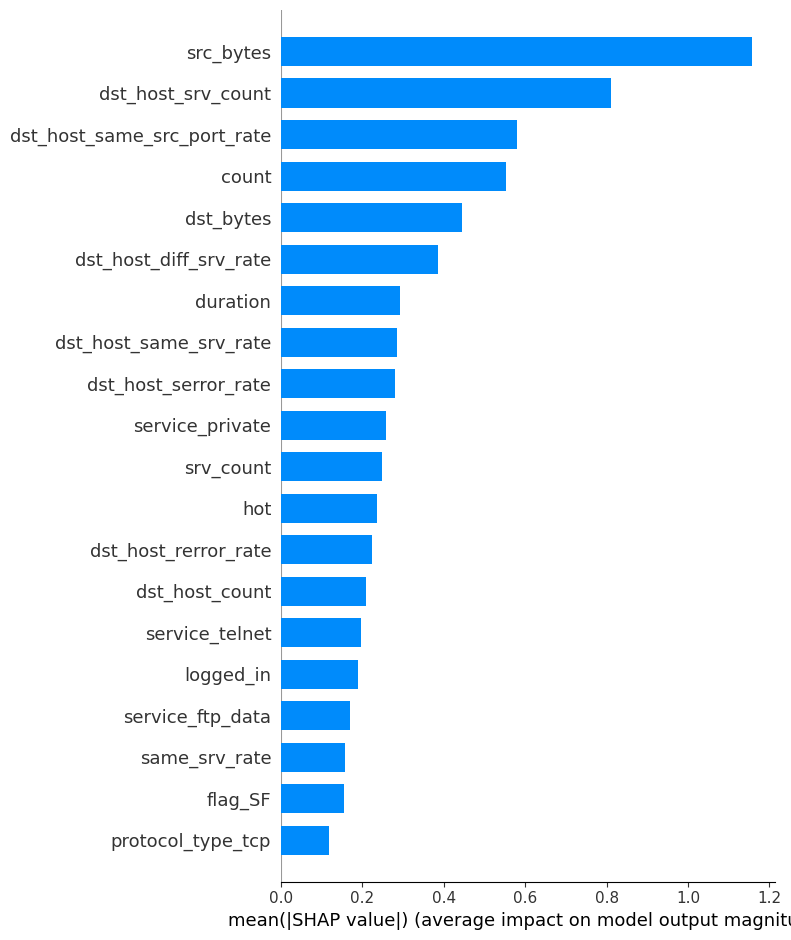

<Figure size 640x480 with 0 Axes>


📊 SHAP — Classe : DoS


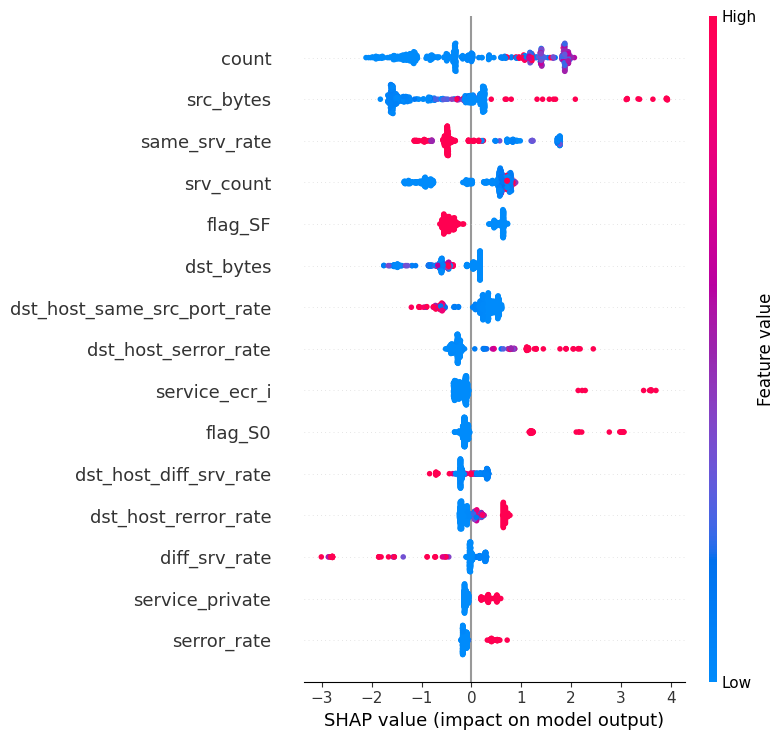

<Figure size 640x480 with 0 Axes>


📊 SHAP — Classe : Probe


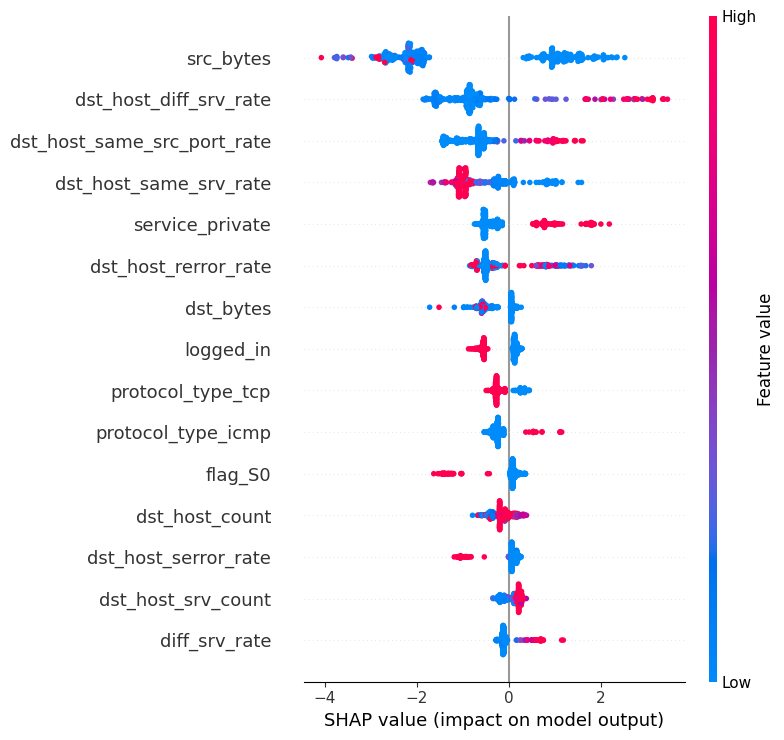

<Figure size 640x480 with 0 Axes>


📊 SHAP — Classe : R2L


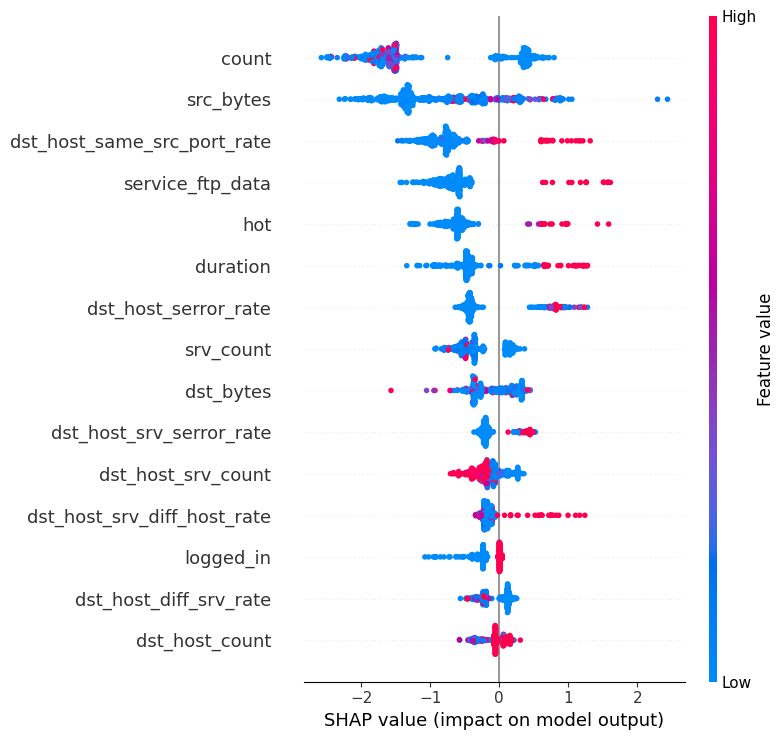

<Figure size 640x480 with 0 Axes>


📊 SHAP — Classe : U2R


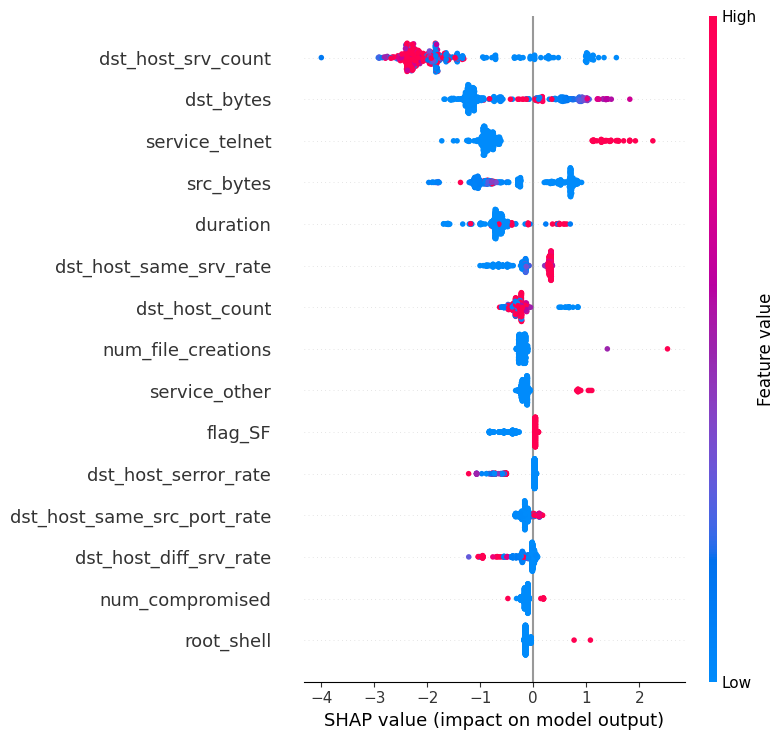

<Figure size 640x480 with 0 Axes>


📊 SHAP — Classe : normal


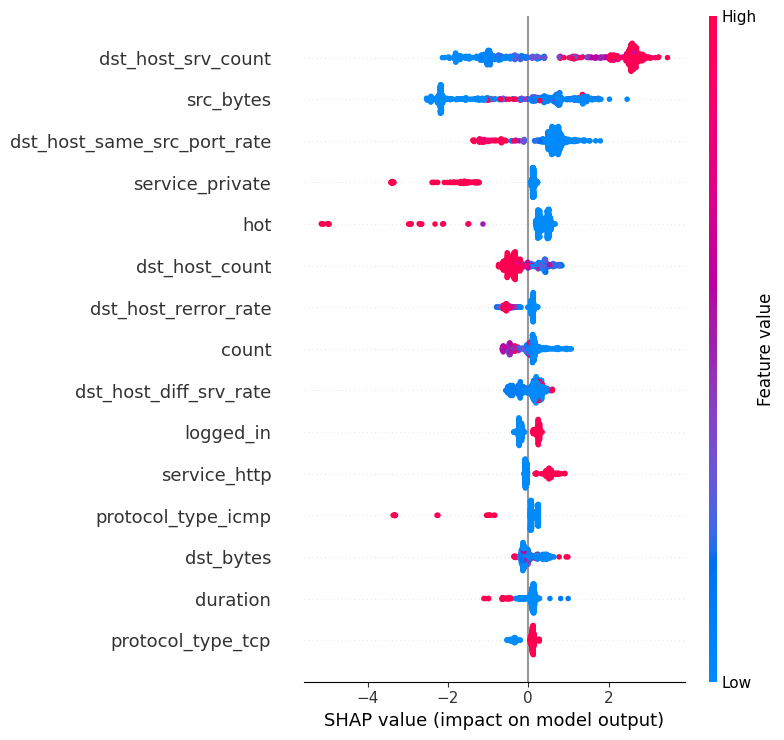

<Figure size 640x480 with 0 Axes>

✅ SHAP terminé.


In [19]:
import shap

print("⏳ Calcul SHAP...")
explainer   = shap.TreeExplainer(best_xgb)
X_shap      = X_test_scaled[:500]
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = np.stack(shap_values, axis=2)

# Importance globale
shap_mean = np.abs(shap_values).mean(axis=2)
shap.summary_plot(shap_mean, X_shap, feature_names=feature_columns,
                  plot_type='bar', max_display=20, show=True)
plt.tight_layout(); plt.show()

# Par classe
for i, cls in enumerate(le.classes_):
    print(f"\n📊 SHAP — Classe : {cls}")
    shap.summary_plot(shap_values[:,:,i], X_shap,
                      feature_names=feature_columns, max_display=15, show=True)
    plt.tight_layout(); plt.show()

print("✅ SHAP terminé.")

In [20]:
cols_raw  = columns[:-1]
train_raw = pd.read_csv("project-ids/data/raw/KDDTrain+.txt", header=None, names=cols_raw+['difficulty_score'])
test_raw  = pd.read_csv("project-ids/data/raw/KDDTest+.txt",  header=None, names=cols_raw+['difficulty_score'])

train_labels = set(train_raw['label'].apply(lambda x: x.split('.')[0].strip()))
test_labels  = set(test_raw['label'].apply(lambda x: x.split('.')[0].strip()))

nouveaux = test_labels - train_labels
print(f"⚠️  Sous-types dans TEST mais absents du TRAIN ({len(nouveaux)}) :")
for l in sorted(nouveaux): print(f"   - {l}")

print("""
📌 CONCLUSION :
   NSL-KDD contient intentionnellement des attaques dans le test set
   absentes du train (Tavallaee et al., 2009).
   Les faibles F1 sur R2L/U2R reflètent cette limite du benchmark,
   et non une erreur de modélisation.
""")

⚠️  Sous-types dans TEST mais absents du TRAIN (17) :
   - apache2
   - httptunnel
   - mailbomb
   - mscan
   - named
   - processtable
   - ps
   - saint
   - sendmail
   - snmpgetattack
   - snmpguess
   - sqlattack
   - udpstorm
   - worm
   - xlock
   - xsnoop
   - xterm

📌 CONCLUSION :
   NSL-KDD contient intentionnellement des attaques dans le test set
   absentes du train (Tavallaee et al., 2009).
   Les faibles F1 sur R2L/U2R reflètent cette limite du benchmark,
   et non une erreur de modélisation.



In [21]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb, 'models/xgb_model.pkl')
joblib.dump(rf_model,  'models/rf_model.pkl')
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(le,        'models/label_encoder.pkl')

with open('models/columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("✅ Modèles sauvegardés :", os.listdir('models'))

✅ Modèles sauvegardés : ['xgb_model.pkl', 'columns.json', 'label_encoder.pkl', 'rf_model.pkl', 'scaler.pkl']


In [22]:
def predict_traffic(raw_df):
    """
    Entrée  : DataFrame avec les colonnes originales NSL-KDD
    Sortie  : labels prédits (normal / DoS / Probe / R2L / U2R)
    """
    X = pd.get_dummies(raw_df, columns=['protocol_type','service','flag'])
    X, _ = X.align(pd.DataFrame(columns=feature_columns), join='right', axis=1, fill_value=0)
    X_sc  = scaler.transform(X)
    preds = best_xgb.predict(X_sc)
    return le.inverse_transform(preds)

# Test sur 5 exemples
sample = test_df.drop('label', axis=1).iloc[:5].copy()
print("🔍 Prédictions sur 5 connexions :")
print(predict_traffic(sample))
print("✅ Pipeline fonctionnel.")

🔍 Prédictions sur 5 connexions :
['DoS' 'DoS' 'normal' 'Probe' 'normal']
✅ Pipeline fonctionnel.


In [25]:
from sklearn.pipeline import Pipeline
import joblib

# Si tu as un scaler séparé, combine-les
from sklearn.pipeline import make_pipeline

final_pipeline = make_pipeline(scaler, best_xgb)
joblib.dump(final_pipeline, '/content/ids_pipeline.pkl')
joblib.dump(le, '/content/label_encoder.pkl')

print("✅ Pipeline final sauvegardé !")

✅ Pipeline final sauvegardé !


In [24]:
!pkill -f streamlit

In [37]:
with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write('''import streamlit as st
import pandas as pd
import numpy as np
import joblib, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

st.set_page_config(page_title="IDS - Network Intrusion Detection", page_icon="shield", layout="wide")

st.markdown("""
<style>
    .main { background-color: #0e1117; }
    .metric-card {
        background: linear-gradient(135deg, #1e2130, #2d3250);
        border-radius: 12px;
        padding: 20px;
        text-align: center;
        border: 1px solid #3d4270;
        margin: 5px;
    }
    .metric-value { font-size: 2.5em; font-weight: bold; margin: 5px 0; }
    .metric-label { font-size: 0.9em; color: #aaa; text-transform: uppercase; letter-spacing: 1px; }
    .alert-box {
        background: linear-gradient(135deg, #3d1515, #5c2020);
        border-left: 4px solid #ff4444;
        border-radius: 8px;
        padding: 15px;
        margin: 10px 0;
    }
    .header-box {
        background: linear-gradient(135deg, #1a1f3a, #2d3561);
        border-radius: 15px;
        padding: 30px;
        text-align: center;
        margin-bottom: 20px;
        border: 1px solid #4a5080;
    }
    .section-title {
        font-size: 1.3em;
        font-weight: bold;
        color: #7eb3ff;
        border-bottom: 2px solid #3d4270;
        padding-bottom: 8px;
        margin: 20px 0 15px 0;
    }
    div[data-testid="stTab"] { font-size: 1.1em; }
</style>
""", unsafe_allow_html=True)

st.markdown("""
<div class="header-box">
    <h1 style="color:#7eb3ff; margin:0; font-size:2.2em;">Shield  Systeme de Detection d Intrusions Reseau</h1>
    <p style="color:#aaa; margin:10px 0 0 0; font-size:1.1em;">Option A — Classification Multi-classe | Dataset NSL-KDD | XGBoost</p>
</div>
""", unsafe_allow_html=True)

COLORS = {"normal":"#4C9BE8","DoS":"#E8593C","Probe":"#F2A623","R2L":"#8B5CF6","U2R":"#10B981"}
ICONS  = {"normal":"green","DoS":"red","Probe":"orange","R2L":"purple","U2R":"brown"}

@st.cache_resource
def load_models():
    xgb = joblib.load("models/xgb_model.pkl")
    sc  = joblib.load("models/scaler.pkl")
    le  = joblib.load("models/label_encoder.pkl")
    with open("models/columns.json") as f:
        cols = json.load(f)
    return xgb, sc, le, cols

xgb_model, scaler, le, feature_columns = load_models()

with st.sidebar:
    st.markdown("### Configuration")
    st.markdown("---")
    threshold  = st.slider("Seuil de confiance minimum", 0.5, 0.99, 0.7, 0.01)
    show_proba = st.checkbox("Afficher probabilites par classe", value=True)
    st.markdown("---")
    st.markdown("### Classes detectees")
    for cls, color in COLORS.items():
        st.markdown(f"<span style=color:{color}>■</span> **{cls}**", unsafe_allow_html=True)
    st.markdown("---")
    st.caption("Projet IDS — 4eme annee Cybersecurite")

columns_nsl = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_score"
]

tab1, tab2, tab3 = st.tabs(["  Detection  ", "  Metriques  ", "  A propos  "])

with tab1:
    st.markdown("<div class=section-title>Charger des donnees reseau</div>", unsafe_allow_html=True)
    uploaded = st.file_uploader("Format NSL-KDD (.txt ou .csv, sans en-tete)", type=["csv","txt"])

    if uploaded:
        df = pd.read_csv(uploaded, header=None, names=columns_nsl, on_bad_lines="skip")
        if "difficulty_score" in df.columns:
            df = df.drop("difficulty_score", axis=1)
        true_labels = df["label"].copy() if "label" in df.columns else None
        X = df.drop(columns=["label"], errors="ignore")

        with st.spinner("Analyse en cours..."):
            X_enc = pd.get_dummies(X, columns=["protocol_type","service","flag"])
            for col in feature_columns:
                if col not in X_enc.columns:
                    X_enc[col] = 0
            X_enc     = X_enc[feature_columns].astype(float)
            X_scaled  = scaler.transform(X_enc)
            preds     = le.inverse_transform(xgb_model.predict(X_scaled))
            probas    = xgb_model.predict_proba(X_scaled)
            confidence= probas.max(axis=1)

        df["Prediction"] = preds
        df["Confiance"]  = confidence.round(3)
        df["Alerte"]     = df["Confiance"] < threshold

        n_total   = len(df)
        n_normal  = int((df["Prediction"]=="normal").sum())
        n_dos     = int((df["Prediction"]=="DoS").sum())
        n_probe   = int((df["Prediction"]=="Probe").sum())
        n_r2l     = int((df["Prediction"]=="R2L").sum())
        n_u2r     = int((df["Prediction"]=="U2R").sum())
        n_alerts  = int(df["Alerte"].sum())
        pct_attack= round((n_total - n_normal) / n_total * 100, 1)

        if pct_attack > 30:
            st.markdown(f"""
            <div class="alert-box">
                <b style="color:#ff6666; font-size:1.1em;">ALERTE — Trafic suspect eleve</b><br>
                <span style="color:#ffaaaa;">{pct_attack}% du trafic analyse est potentiellement malveillant ({n_total - n_normal:,} connexions)</span>
            </div>
            """, unsafe_allow_html=True)

        st.markdown("<div class=section-title>Tableau de bord</div>", unsafe_allow_html=True)
        st.markdown(f"""
        <div style="display:flex; gap:10px; flex-wrap:wrap; margin-bottom:15px;">
            <div class="metric-card" style="flex:1; border-top:3px solid #7eb3ff;">
                <div class="metric-label">Total Connexions</div>
                <div class="metric-value" style="color:#7eb3ff;">{n_total:,}</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #4C9BE8;">
                <div class="metric-label">Normal</div>
                <div class="metric-value" style="color:#4C9BE8;">{n_normal:,}</div>
                <div style="color:#888; font-size:0.85em;">{round(n_normal/n_total*100,1)}%</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #E8593C;">
                <div class="metric-label">DoS</div>
                <div class="metric-value" style="color:#E8593C;">{n_dos:,}</div>
                <div style="color:#888; font-size:0.85em;">{round(n_dos/n_total*100,1)}%</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #F2A623;">
                <div class="metric-label">Probe</div>
                <div class="metric-value" style="color:#F2A623;">{n_probe:,}</div>
                <div style="color:#888; font-size:0.85em;">{round(n_probe/n_total*100,1)}%</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #8B5CF6;">
                <div class="metric-label">R2L</div>
                <div class="metric-value" style="color:#8B5CF6;">{n_r2l:,}</div>
                <div style="color:#888; font-size:0.85em;">{round(n_r2l/n_total*100,1)}%</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #10B981;">
                <div class="metric-label">U2R</div>
                <div class="metric-value" style="color:#10B981;">{n_u2r:,}</div>
                <div style="color:#888; font-size:0.85em;">{round(n_u2r/n_total*100,1)}%</div>
            </div>
            <div class="metric-card" style="flex:1; border-top:3px solid #ff4444;">
                <div class="metric-label">Alertes</div>
                <div class="metric-value" style="color:#ff4444;">{n_alerts:,}</div>
                <div style="color:#888; font-size:0.85em;">confiance < {threshold}</div>
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("<div class=section-title>Visualisations</div>", unsafe_allow_html=True)
        col1, col2 = st.columns(2)

        with col1:
            fig, ax = plt.subplots(figsize=(7,4), facecolor="#1e2130")
            ax.set_facecolor("#1e2130")
            counts = df["Prediction"].value_counts()
            bars = ax.bar(counts.index, counts.values,
                         color=[COLORS.get(l,"gray") for l in counts.index],
                         width=0.6, edgecolor="none", zorder=3)
            for bar, val in zip(bars, counts.values):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                       f"{val:,}", ha="center", va="bottom", color="white", fontsize=9)
            ax.set_title("Distribution des classes predites", color="white", pad=15, fontsize=12)
            ax.tick_params(colors="white")
            ax.spines[:].set_visible(False)
            ax.yaxis.grid(True, color="#2d3250", zorder=0)
            ax.set_axisbelow(True)
            plt.tight_layout()
            st.pyplot(fig)

        with col2:
            fig, ax = plt.subplots(figsize=(7,4), facecolor="#1e2130")
            ax.set_facecolor("#1e2130")
            wedges, texts, autotexts = ax.pie(
                counts.values,
                labels=counts.index,
                colors=[COLORS.get(l,"gray") for l in counts.index],
                autopct="%1.1f%%",
                startangle=140,
                wedgeprops=dict(edgecolor="#1e2130", linewidth=2)
            )
            for t in texts: t.set_color("white")
            for t in autotexts: t.set_color("white"); t.set_fontsize(9)
            ax.set_title("Repartition en pourcentage", color="white", pad=15, fontsize=12)
            plt.tight_layout()
            st.pyplot(fig)

        fig, ax = plt.subplots(figsize=(12,3), facecolor="#1e2130")
        ax.set_facecolor("#1e2130")
        ax.hist(confidence, bins=60, color="#4C9BE8", edgecolor="none", alpha=0.8)
        ax.axvline(threshold, color="#ff4444", linestyle="--", linewidth=2,
                   label=f"Seuil = {threshold}")
        ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 1000],
                         0, threshold, alpha=0.1, color="#ff4444")
        ax.set_title("Distribution de la confiance des predictions", color="white", fontsize=12)
        ax.tick_params(colors="white")
        ax.spines[:].set_visible(False)
        ax.yaxis.grid(True, color="#2d3250")
        ax.legend(facecolor="#2d3250", labelcolor="white")
        plt.tight_layout()
        st.pyplot(fig)

        st.markdown("<div class=section-title>Detail des connexions</div>", unsafe_allow_html=True)
        if show_proba:
            proba_df = pd.DataFrame(probas, columns=[f"P({c})" for c in le.classes_]).round(3)
            display_df = pd.concat([df[["Prediction","Confiance","Alerte"]].reset_index(drop=True), proba_df], axis=1)
        else:
            display_df = df[["Prediction","Confiance","Alerte"]]
        st.dataframe(display_df, use_container_width=True, height=300)

        alerts = df[df["Alerte"]]
        if len(alerts) > 0:
            st.markdown(f"""
            <div class="alert-box">
                <b style="color:#ff6666;">  {len(alerts):,} connexions avec confiance inferieure a {threshold}</b>
            </div>
            """, unsafe_allow_html=True)

        # ═══════════════════════════════════════════════
        # PERFORMANCE — VERSION AMELIOREE
        # ═══════════════════════════════════════════════
        if true_labels is not None:
            st.markdown("<div class=section-title>Performance du modele</div>", unsafe_allow_html=True)

            dos_l   = ["back","land","neptune","pod","smurf","teardrop","apache2","udpstorm","processtable","worm","mailbomb"]
            probe_l = ["ipsweep","nmap","portsweep","satan","mscan","saint"]
            r2l_l   = ["ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster"]

            def map_label(l):
                l = l.split(".")[0].strip()
                if l=="normal": return "normal"
                elif l in dos_l: return "DoS"
                elif l in probe_l: return "Probe"
                elif l in r2l_l: return "R2L"
                else: return "U2R"

            y_true = true_labels.apply(map_label)

            classes_order = ["DoS","Probe","R2L","U2R","normal"]
            prec, rec, f1, sup = precision_recall_fscore_support(
                y_true, preds, labels=classes_order, zero_division=0
            )
            acc = (np.array(preds) == np.array(y_true)).mean()
            f1_weighted = sum(f1[i]*sup[i] for i in range(len(f1))) / sum(sup)

            # ── Banniere metriques globales ──
            st.markdown(f"""
            <div style="background:linear-gradient(135deg,#1a2744,#2d3561);border-radius:12px;
                        padding:20px 30px;margin-bottom:20px;border:1px solid #3d4270;
                        display:flex;align-items:center;gap:40px;flex-wrap:wrap;">
                <div>
                    <div style="color:#aaa;font-size:0.8em;text-transform:uppercase;letter-spacing:1px;">Accuracy Globale</div>
                    <div style="color:#7eb3ff;font-size:3em;font-weight:bold;line-height:1.1;">{acc:.1%}</div>
                </div>
                <div style="border-left:1px solid #3d4270;padding-left:40px;">
                    <div style="color:#aaa;font-size:0.8em;text-transform:uppercase;letter-spacing:1px;">F1 Weighted</div>
                    <div style="color:#10B981;font-size:3em;font-weight:bold;line-height:1.1;">{f1_weighted:.2f}</div>
                </div>
                <div style="border-left:1px solid #3d4270;padding-left:40px;">
                    <div style="color:#aaa;font-size:0.8em;text-transform:uppercase;letter-spacing:1px;">Connexions testees</div>
                    <div style="color:#F2A623;font-size:3em;font-weight:bold;line-height:1.1;">{len(y_true):,}</div>
                </div>
                <div style="border-left:1px solid #3d4270;padding-left:40px;">
                    <div style="color:#aaa;font-size:0.8em;text-transform:uppercase;letter-spacing:1px;">Classes detectees</div>
                    <div style="color:#8B5CF6;font-size:3em;font-weight:bold;line-height:1.1;">5 / 5</div>
                </div>
            </div>
            """, unsafe_allow_html=True)

            # ── Cards par classe ──
            cards_html = '<div style="display:flex;gap:10px;margin-bottom:24px;flex-wrap:wrap;">'
            cls_colors = {"DoS":"#E8593C","Probe":"#F2A623","R2L":"#8B5CF6","U2R":"#10B981","normal":"#4C9BE8"}

            for i, cls in enumerate(classes_order):
                color   = cls_colors[cls]
                f1_val  = f1[i]
                p_val   = prec[i]
                r_val   = rec[i]
                s_val   = int(sup[i])
                bar_w   = int(f1_val * 100)
                # Couleur badge F1
                if f1_val >= 0.8:
                    badge_color = "#10B981"
                elif f1_val >= 0.5:
                    badge_color = "#F2A623"
                else:
                    badge_color = "#E8593C"

                cards_html += f"""
                <div style="flex:1;min-width:150px;background:#1e2130;border-radius:12px;
                            padding:18px;border:1px solid #2d3250;border-top:3px solid {color};">
                    <div style="color:{color};font-weight:bold;font-size:1.15em;margin-bottom:12px;">{cls}</div>
                    <div style="margin-bottom:8px;">
                        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:4px;">
                            <span style="color:#aaa;font-size:0.75em;text-transform:uppercase;">F1-Score</span>
                            <span style="background:{badge_color};color:white;padding:1px 7px;
                                         border-radius:10px;font-size:0.8em;font-weight:bold;">{f1_val:.2f}</span>
                        </div>
                        <div style="background:#2d3250;border-radius:4px;height:8px;">
                            <div style="background:linear-gradient(90deg,{color},{badge_color});
                                        width:{bar_w}%;height:8px;border-radius:4px;
                                        transition:width 0.3s;"></div>
                        </div>
                    </div>
                    <div style="display:flex;justify-content:space-between;margin-top:12px;
                                border-top:1px solid #2d3250;padding-top:10px;">
                        <div style="text-align:center;">
                            <div style="color:#aaa;font-size:0.68em;text-transform:uppercase;">Precision</div>
                            <div style="color:white;font-size:1em;font-weight:bold;">{p_val:.2f}</div>
                        </div>
                        <div style="text-align:center;">
                            <div style="color:#aaa;font-size:0.68em;text-transform:uppercase;">Rappel</div>
                            <div style="color:white;font-size:1em;font-weight:bold;">{r_val:.2f}</div>
                        </div>
                        <div style="text-align:center;">
                            <div style="color:#aaa;font-size:0.68em;text-transform:uppercase;">Support</div>
                            <div style="color:white;font-size:1em;font-weight:bold;">{s_val:,}</div>
                        </div>
                    </div>
                </div>"""
            cards_html += '</div>'
            st.markdown(cards_html, unsafe_allow_html=True)

            # ── Matrice de confusion ──
            st.markdown("<div style='color:#7eb3ff;font-weight:bold;font-size:1.1em;margin-bottom:12px;'>Matrice de Confusion</div>", unsafe_allow_html=True)
            cls_list = list(le.classes_)
            cm  = confusion_matrix(y_true, preds, labels=cls_list)
            fig, ax = plt.subplots(figsize=(8, 6), facecolor="#1e2130")
            ax.set_facecolor("#1e2130")
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                       xticklabels=cls_list, yticklabels=cls_list, ax=ax,
                       linewidths=0.5, linecolor="#2d3250",
                       annot_kws={"size":12, "weight":"bold"})
            ax.set_title("Matrice de Confusion", color="white", fontsize=14, pad=15)
            ax.tick_params(colors="white", labelsize=11)
            ax.set_xlabel("Predit", color="#aaa", fontsize=12)
            ax.set_ylabel("Reel", color="#aaa", fontsize=12)
            plt.tight_layout()
            st.pyplot(fig)

    else:
        st.markdown("""
        <div style="text-align:center; padding:60px; background:#1e2130; border-radius:15px; border:2px dashed #3d4270;">
            <div style="font-size:3em;">upload</div>
            <h3 style="color:#7eb3ff;">Uploadez votre fichier NSL-KDD</h3>
            <p style="color:#888;">Format : 43 colonnes NSL-KDD (avec difficulty_score)<br>Extensions acceptees : .txt, .csv</p>
        </div>
        """, unsafe_allow_html=True)

with tab2:
    st.markdown("<div class=section-title>Modeles implementes</div>", unsafe_allow_html=True)
    data = {
        "Modele": ["Logistic Regression","Decision Tree","Random Forest","XGBoost (final)"],
        "Type":   ["Baseline","Baseline","Fine-tune","Fine-tune"],
        "Statut": ["Entraine","Entraine","Entraine","Selectionne"]
    }
    st.dataframe(pd.DataFrame(data), use_container_width=True)
    st.info("Les metriques exactes (F1, Accuracy, AUC) sont affichees dans le notebook Colab apres entraînement.")

with tab3:
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("""
        ### Projet
        **Titre :** Detection d Intrusions Reseau par ML
        **Option :** A — Classification Multi-classe
        **Dataset :** NSL-KDD (125 973 enregistrements)
        **Niveau :** 4eme annee Cybersecurite

        ### Pipeline
        1. Chargement NSL-KDD
        2. Regroupement en 5 classes
        3. One-hot encoding
        4. SMOTETomek (reequilibrage)
        5. RandomizedSearchCV
        6. XGBoost final
        """)
    with col2:
        st.markdown("""
        ### Classes detectees
        | Classe | Description |
        |--------|-------------|
        | Normal | Trafic legitime |
        | DoS | Denial of Service |
        | Probe | Reconnaissance |
        | R2L | Remote to Local |
        | U2R | User to Root |

        ### Modele final
        **XGBoost** avec hyperparametres optimises par RandomizedSearchCV sur 3-fold CV
        """)

st.markdown("---")
st.caption("Projet IDS — 4eme annee Cybersecurite | ML-based Network Intrusion Detection System")
''')

print("✅ app.py mis a jour !")

✅ app.py mis a jour !


In [27]:
!pkill -f streamlit
!pkill -f lt

In [29]:
!pip install streamlit pyngrok -q
print("✅ Installé !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 69.5 MB/s eta 0:00:00
✅ Installé !


In [34]:
import subprocess, time

subprocess.Popen([
    "streamlit", "run", "/content/app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
      "--theme.base=dark"
])
time.sleep(5)
print("✅ Streamlit lancé !")

✅ Streamlit lancé !


In [35]:
# Tue streamlit et localtunnel
!pkill -f streamlit
!pkill -f lt

import time
time.sleep(2)

# Relance avec le tunnel intégré Colab
import subprocess
subprocess.Popen([
    "streamlit", "run", "/content/app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false",
    "--server.runOnSave=true"
])
time.sleep(3)

from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-usw4c2-125vlcsdr3qy9-c.us-west4-2.prod.colab.dev
